# Screening, end to end

The pipeline matverse exists for: take a list of candidate structures, remove
the ones that are broken, relax what remains, work out which are
thermodynamically plausible, and shortlist — keeping the reasoning attached to
the object rather than in your head.

Everything here runs on `emt`, ASE's effective-medium theory, which ships with
ASE and needs no download. The library is the Al–Ni–Cu system: three elemental
metals from published lattice parameters, plus hypothetical ordered
intermetallics built on the L1₂ prototype — the [Cu₃Au
structure](https://doi.org/10.1103/PhysRev.49.122) that most fcc-based ordered
alloys adopt.

The elementals are real; the intermetallics are candidates. That is what a
screen looks like.

In [1]:
import matverse as mv
import numpy as np

mv.pl.set_style()

matverse 0.1.12 — 121 functions


## Build a dataset

`mv.datasets.metals` gives the elemental fcc metals at their measured
room-temperature lattice parameters.

In [2]:
elemental = mv.datasets.metals(["Al", "Cu", "Ni"])
elemental.obs[["name", "lattice_parameter"]]

,name,lattice_parameter
0,Al,4.0495
1,Cu,3.6149
2,Ni,3.5240


The candidates are L1₂ orderings of the same three elements, plus a B2 AlNi.
Both prototypes are built by hand, because that is what a candidate is — a
structure nobody has computed yet.

In [3]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    """Cu3Au prototype: guest on the corner, host on the faces."""
    return Structure(Lattice.cubic(a),
                     [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


def b2(a_symbol, b_symbol, a):
    """CsCl prototype."""
    return Structure(Lattice.cubic(a), [a_symbol, b_symbol],
                     [[0, 0, 0], [.5, .5, .5]])


candidates = [
    l12("Al", "Cu", 3.90),      # Al3Cu
    l12("Cu", "Al", 3.70),      # AlCu3
    l12("Al", "Ni", 3.78),      # Al3Ni
    b2("Al", "Ni", 2.89),       # AlNi
]

Put the published elementals and the candidates into one object. Building it in
a single call keeps the row names sequential, which matters more than it sounds
— every later table is indexed by them.

In [4]:
md = mv.data.from_structures(mv.structures(elemental) + candidates)
md

AnnData object with n_obs × n_vars = 7 × 3
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is'
    obsm: 'structures'

Seven materials, three elements. `X` is already the composition matrix and `var`
is already the periodic table restricted to Al, Ni and Cu — you did not ask for
either, because composition is intrinsic to a material rather than derived from
it.

In practice you would load from disk or from a database instead:

```python
md = mv.data.from_cif('candidates/')
md = mv.data.from_mp({'elements': ['Al', 'Ni'], 'num_elements': (2, 2)})
```

## Standardise and describe

In [5]:
mv.pp.standardize(md)      # primitive + conventional + spacegroup
mv.pp.describe(md)         # formula, nsites, volume, density, n_elements

md.obs[["formula", "spacegroup", "n_elements"]]

,formula,spacegroup,n_elements
0,Al,Fm-3m,1
1,Cu,Fm-3m,1
2,Ni,Fm-3m,1
3,Al3Cu,Pm-3m,2
4,AlCu3,Pm-3m,2
5,Al3Ni,Pm-3m,2
6,AlNi,Pm-3m,2


`standardize` deposits two new structure variants rather than replacing the
input. Every later call names which one it wants.

In [6]:
mv.variants(md)

['input', 'primitive', 'conventional']

## Throw out what is broken

`qc` is the analogue of `scanpy.pp.calculate_qc_metrics`, and it exists for the
same reason: a generated or database structure with atoms 0.1 Å apart is a
broken cell, not an exotic one. Relaxing it wastes the calculator's time and
pollutes the hull.

In [7]:
mv.pp.qc(md)
md.obs[["formula", "min_distance", "is_ordered", "is_valid", "qc_reason"]]

,formula,min_distance,is_ordered,is_valid,qc_reason
0,Al,2.863429,True,True,
1,Cu,2.556120,True,True,
2,Ni,2.491844,True,True,
3,Al3Cu,2.757716,True,True,
4,AlCu3,2.616295,True,True,
5,Al3Ni,2.672864,True,True,
6,AlNi,2.502813,True,True,


In [8]:
md = mv.pp.filter_materials(md)
mv.provenance(md)[-1]

"pp.filter_materials(flag='is_valid', n_dropped=0)"

This is one of the few calls that returns instead of depositing, because AnnData
cannot drop rows in place — and it records how many it dropped.

Duplicates are worth removing before you spend compute on them twice:

In [9]:
mv.pp.dedup(md)
md.uns["dedup"]

{'source': 'input',
 'n_blocks': 7,
 'n_duplicates': 0,
 'n_unique': 7,
 'matcher': {'ltol': 0.2, 'stol': 0.3, 'angle_tol': 5.0}}

`dedup` blocks on `(reduced formula, space group)` before running pymatgen's
`StructureMatcher` inside each block. An all-pairs comparison is quadratic and
unusable past a few thousand candidates; blocking makes the expensive part
local.

## Relax

In [10]:
mv.calc.relax(md, level="emt", fmax=0.05)

md.obs[["formula", "energy_emt", "energy_per_atom_emt",
        "relax_converged_emt"]].round(4)

,formula,energy_emt,energy_per_atom_emt,relax_converged_emt
0,Al,-0.0062,-0.0016,True
1,Cu,-0.0198,-0.0050,True
2,Ni,-0.0304,-0.0076,True
3,Al3Cu,0.3184,0.0796,True
4,AlCu3,0.4373,0.1093,True
5,Al3Ni,0.7315,0.1829,True
6,AlNi,0.8612,0.4306,True


The relaxed geometry becomes its own variant, `relaxed_emt`, rather than
overwriting the input — so "which structure was this energy computed on" stays
answerable from the object alone.

The level records what produced it:

In [11]:
mv.level_info(md, "emt")

{'kind': 'classical',
 'method': 'EMT',
 'reference': None,
 'surrogate': True,
 'license': 'LGPL-2.1',
 'uncertainty': None,
 'note': 'ASE effective-medium theory. Parameterised only for Al Cu Ag Au Ni Pd Pt H C N O — enough to exercise a pipeline, not enough to screen with.',
 'source': 'input',
 'fmax': 0.05,
 'steps': 200,
 'n_failed': 0}

`surrogate: True` and `license: 'LGPL-2.1'` are not decoration. The first is
what `mv.thermo.hull` checks before it agrees to mix two levels; the second is
what `mv.calc.check_licenses` reads when you need to know whether a result can
go in a commercial report.

## Build a hull

In [12]:
mv.thermo.hull(md, level="emt", source="relaxed_emt")

md.obs[["formula", "e_above_hull_emt", "is_stable_emt",
        "decomposes_to_emt"]].round(4)

/scratch/users/steorra/analysis/omicverse_dev/matverse/matverse/_registry.py:346: UserWarning: hull for level 'emt' was built over this dataset's own compositions only, so e_above_hull is relative to these candidates and not to the known phase diagram. Pass references= to make it absolute; see uns['phase_diagram']['closed_system'].
  return func(*args, **kwargs)


,formula,e_above_hull_emt,is_stable_emt,decomposes_to_emt
0,Al,0.0000,True,Al:1.00
1,Cu,0.0000,True,Cu:1.00
2,Ni,0.0000,True,Ni:1.00
3,Al3Cu,0.0820,False,Al:0.75 + Cu:0.25
4,AlCu3,0.1134,False,Cu:0.75 + Al:0.25
5,Al3Ni,0.1859,False,Al:0.75 + Ni:0.25
6,AlNi,0.4352,False,Al:0.50 + Ni:0.50


```{warning}
That call emitted a warning, and you should read it. With no `references=`, the
hull is built over **this dataset's own compositions**, which makes
`e_above_hull` a statement about which of your candidates is lowest — not about
whether any of them is stable. Screening 40 generated oxides against each other
will happily report several as "on the hull" when all 40 decompose.
```

Two things about this particular table are worth saying plainly rather than
leaving for a reader to trip over.

EMT's energy zero is the pure element at its equilibrium lattice constant, so
the elemental energies come out at essentially zero and every intermetallic is
positive by construction. **This hull cannot find a stable alloy.** It is
demonstrating the pipeline, not the Al–Ni–Cu phase diagram.

And Al₃Ni is a real, stable phase — it just is not the L1₂ polymorph built
above; the observed one is orthorhombic. A number attached to a prototype says
nothing about a compound that adopts a different structure. Both of those are
ordinary screening mistakes, and both are visible here because the level of
theory and the structure variant are recorded rather than assumed.

In [13]:
md.uns["phase_diagram"]["closed_system"]

True

The object records which kind of number you have, so a later reader does not
have to guess.

To make it absolute, pass the known competing phases:

```python
refs = mv.thermo.references_from_mp(['Al', 'Ni', 'Cu'])   # needs mp-api
mv.thermo.hull(md, level='pbe', references=refs)
```

Note the level changed. Materials Project entries are PBE+U with fitted
corrections; putting them on a hull with EMT energies is not a hull of anything,
and `mv.thermo.hull` raises `LevelMismatch` rather than letting you.

## Shortlist

Ask for something light and not too far above the hull — two criteria that pull
in different directions, which is what makes it a screen rather than a sort.

In [14]:
mv.screen.filter(md, e_above_hull_emt__lt=0.12, density__lt=8.0)

md.uns["screens"]["passes"]

{'criteria': {'e_above_hull_emt__lt': 0.12, 'density__lt': 8.0},
 'n_pass': 3,
 'n_total': 7}

In [15]:
md.obs[["formula", "e_above_hull_emt", "density", "passes"]].round(4)

,formula,e_above_hull_emt,density,passes
0,Al,0.0000,2.6988,True
1,Cu,0.0000,8.9353,False
2,Ni,0.0000,8.9082,False
3,Al3Cu,0.0820,4.0448,True
4,AlCu3,0.1134,7.1341,True
5,Al3Ni,0.1859,4.2932,False
6,AlNi,0.4352,5.8940,False


The screen deposits a boolean column and the criteria that produced it. It does
**not** return a shorter list, because which criterion a candidate failed is a
result. Subset when you actually want the short list:

```python
shortlist = md[md.obs['passes']]
```

When more than one objective matters and no single column decides:

In [16]:
mv.screen.pareto(md, {"e_above_hull_emt": "min", "density": "min"})
md.obs[["formula", "e_above_hull_emt", "density", "pareto",
        "pareto_rank"]].round(4)

,formula,e_above_hull_emt,density,pareto,pareto_rank
0,Al,0.0000,2.6988,True,0.0
1,Cu,0.0000,8.9353,False,2.0
2,Ni,0.0000,8.9082,False,1.0
3,Al3Cu,0.0820,4.0448,False,1.0
4,AlCu3,0.1134,7.1341,False,2.0
5,Al3Ni,0.1859,4.2932,False,2.0
6,AlNi,0.4352,5.8940,False,3.0


`pareto_rank` keeps the second-best trade-offs reachable instead of discarding
everything that is not optimal.

Text(0.5, 1.0, 'stability against density')

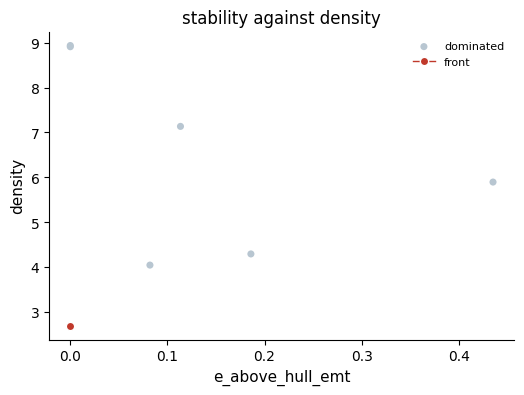

In [17]:
ax = mv.pl.pareto(md, "e_above_hull_emt", "density")
ax.set_title("stability against density")

## What the object remembers

In [18]:
for step in mv.provenance(md):
    print(step)

data.from_structures
pp.standardize(source='input', symprec=0.01)
pp.describe(source='input')
pp.qc(source='input', min_distance=0.5, require_charge_balance=False)
pp.filter_materials(flag='is_valid', n_dropped=0)
pp.dedup(source='input', symprec=0.1)
calc.relax(level='emt', source='input', fmax=0.05, key_added='relaxed_emt')
thermo.hull(level='emt', source='relaxed_emt', n_references=0)
screen.filter(name='passes', e_above_hull_emt__lt=0.12, density__lt=8.0)
screen.pareto(name='pareto', e_above_hull_emt='min', density='min')


Parameters are recorded with each call, so the history replays as code rather
than reading as a list of verbs.

## Save it

```python
md.write_h5ad('screen.h5ad')
```

Structures, descriptors, level records and provenance all survive, and the file
is an ordinary `h5ad` that anndata can read without matverse installed.

```{seealso}
[Chemical space](chemical_space.ipynb) picks up from this object and asks what
distinguishes the candidates that passed.
```